<a href="https://colab.research.google.com/github/mahalakshmi1234567640/maha/blob/main/Student_Mark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Student Mark.csv to Student Mark.csv


In [ ]:
import pandas as pd
df=pd.read_csv('Student Mark.csv')
print(df.head())

  Student Name  Tamil  English  Maths  Phy  C++  Che  Python  Java
0         maha     98       97     96   96   95   94      93    92
1      lakshmi     67       56     76   76   86   86      86    87
2      murugan     87       56     67   87   67   87      56    86
3        Adhav     56       87     67   85   57   85      75    89
4       sindhu     98       68     54   89   67   67      87    78


In [ ]:
subjects = ['Tamil', 'English', 'Maths', 'Phy', 'C++','Che','Python','Java']

df['Total_Marks'] = df [subjects].sum(axis=1)

df['Average'] = df [subjects].mean(axis=1)

print(df[['Student Name', 'Total_Marks', 'Average']])

  Student Name  Total_Marks  Average
0         maha          761   95.125
1      lakshmi          620   77.500
2      murugan          593   74.125
3        Adhav          601   75.125
4       sindhu          608   76.000
5       varsha          181   22.625
6       sahana          579   72.375
7       ragavi          222   27.750
8          anu          556   69.500
9          abi          604   75.500


In [ ]:
weak_students=df[df['Status'] =='Fail']
print("Weak Students")
print(weak_students [['Student Name', 'Average']])

Weak Students
  Student Name  Average
5       varsha   22.625
7       ragavi   27.750


In [ ]:
def assign_grade (avg):
 if avg >= 90:
  return 'A+'
 elif avg >= 80:
  return 'A'
 elif avg >= 70:
  return 'B'
 elif avg >= 60:
  return 'C'
 elif avg >= 50:
  return 'D'
 else:
  return 'F'


df['Grade']=df['Average'].apply(assign_grade)
df['Status']= np.where(df['Average'] >= 50, 'Pass', 'Fail')
print(df[['Student Name', 'Average', 'Grade', 'Status']])

  Student Name  Average Grade Status
0         maha   95.125    A+   Pass
1      lakshmi   77.500     B   Pass
2      murugan   74.125     B   Pass
3        Adhav   75.125     B   Pass
4       sindhu   76.000     B   Pass
5       varsha   22.625     F   Fail
6       sahana   72.375     B   Pass
7       ragavi   27.750     F   Fail
8          anu   69.500     C   Pass
9          abi   75.500     B   Pass


In [ ]:
topper=df.loc[df['Average'].idxmax()]
print("Top Performer")
print("Name:", topper ['Student Name'])
print("Average:", topper ['Average'])
print("Grade:", topper ['Grade'])

Top Performer
Name: maha
Average: 95.125
Grade: A+


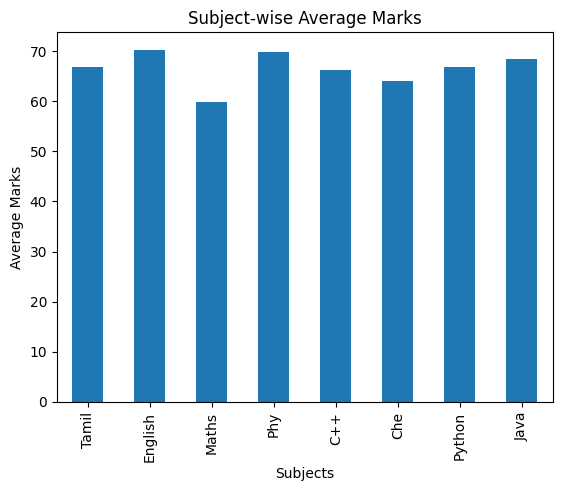

In [ ]:
subject_avg= df[['Tamil', 'English', 'Maths', 'Phy','C++','Che','Python','Java']].mean()
subject_avg.plot(kind='bar')
plt.title("Subject-wise Average Marks")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.show()

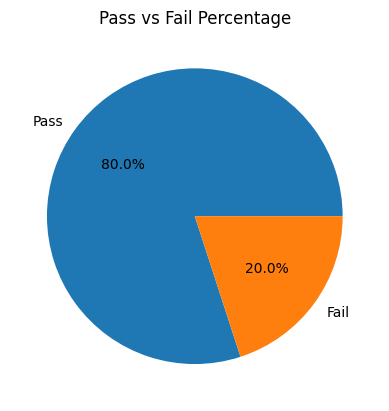

In [ ]:
Status_count = df['Status'].value_counts()

plt.pie(Status_count,
        labels=Status_count.index,
        autopct='%1.1f%%')
plt.title("Pass vs Fail Percentage")
plt.show()

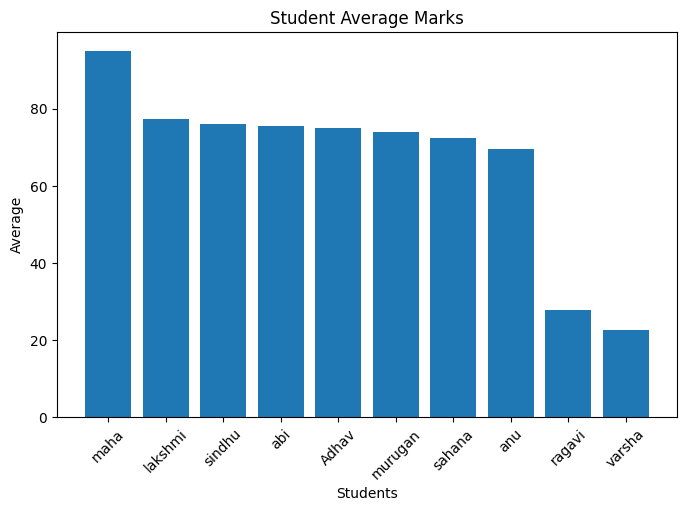

In [ ]:
top_students = df.sort_values (by='Average', ascending=False)
plt.figure(figsize=(8,5))
plt.bar(top_students['Student Name'],
        top_students['Average'])
plt.title("Student Average Marks")
plt.xlabel("Students")
plt.ylabel("Average")
plt.xticks (rotation=45)
plt.show()

In [ ]:


print("Highest Performing Subject:", subject_avg.idxmax())

print("Lowest Performing Subject:", subject_avg.idxmin())

print("Pass Percentage:", round((df['Status']=='Pass').mean()*100,2),"%")

print("Class Average:", round (df ['Average'].mean(),2))

Highest Performing Subject: English
Lowest Performing Subject: Maths
Pass Percentage: 80.0 %
Class Average: 66.56


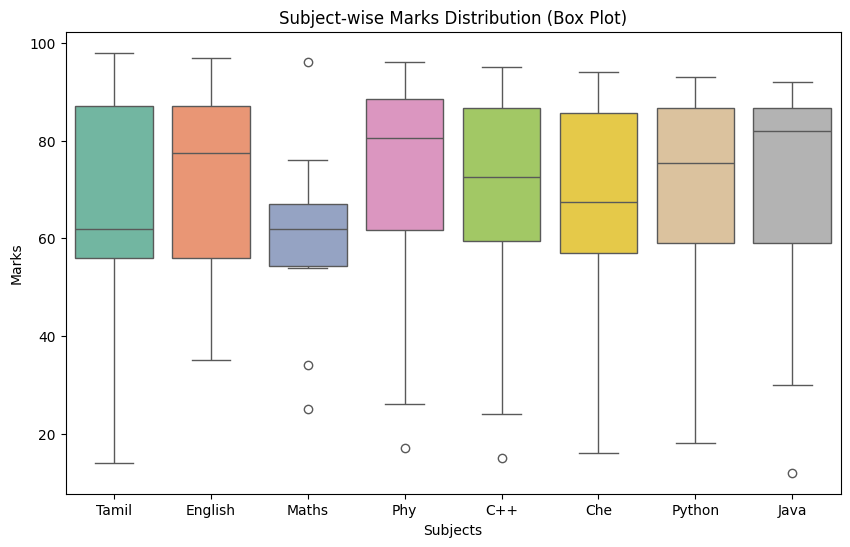

In [ ]:
# 3. Box Plot for Subject Marks Distribution
plt.figure(figsize=(10, 6))

# Melting or selecting data so seaborn can plot multiple columns easily
sns.boxplot(data=df[['Tamil', 'English', 'Maths', 'Phy', 'C++','Che','Python','Java']], palette='Set2')

plt.title('Subject-wise Marks Distribution (Box Plot)')
plt.xlabel('Subjects')
plt.ylabel('Marks')
plt.show()

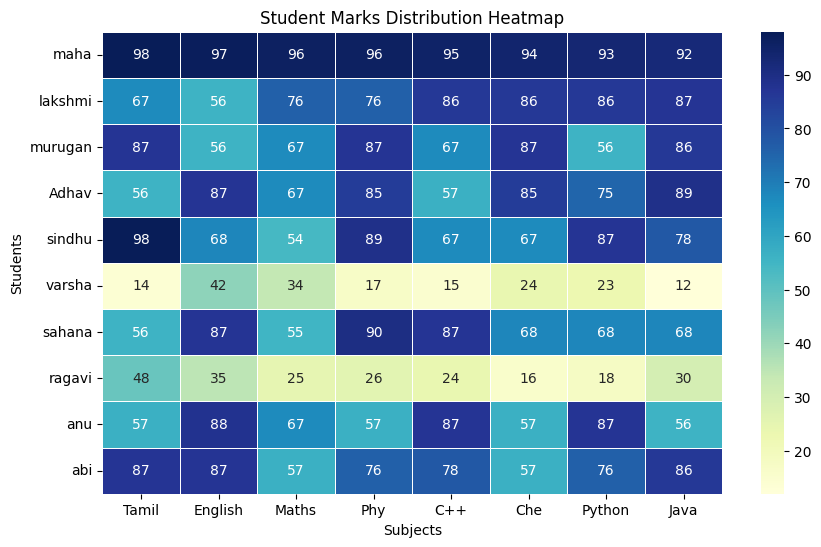

In [ ]:
# 2. Student Marks Heatmap
plt.figure(figsize=(10, 6))

# Setting Student_name as the index so it shows on the y-axis
marks_heatmap_df = df.set_index('Student Name')[['Tamil', 'English', 'Maths', 'Phy', 'C++','Che','Python','Java']]

# Generating the heatmap
sns.heatmap(marks_heatmap_df, annot=True, cmap='YlGnBu', fmt="g", linewidths=0.5)

plt.title('Student Marks Distribution Heatmap')
plt.ylabel('Students')
plt.xlabel('Subjects')
plt.show()

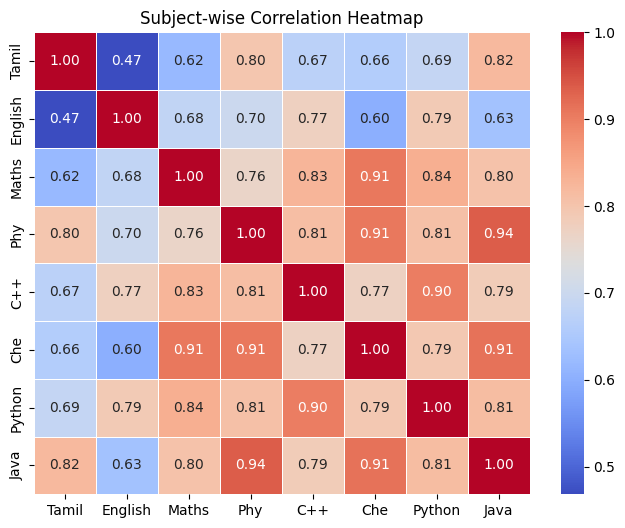

In [ ]:
# 1. Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Subsetting only the subject marks columns for correlation
subjects_df = df[['Tamil', 'English', 'Maths', 'Phy', 'C++','Che','Python','Java']]
correlation_matrix = subjects_df.corr()

# Generating the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Subject-wise Correlation Heatmap')
plt.show()